In [15]:
from pyspark.sql import SparkSession

In [16]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("PySpark-Colab") \
    .getOrCreate()

In [17]:
meta_path = "meta_appliances.jsonl"

# Set Spark to be case-sensitive for column names during schema inference
spark.conf.set("spark.sql.caseSensitive", "true")

meta_df = (
    spark.read
    .option("multiLine", "false")
    .json(meta_path)
)

display(meta_df)


DataFrame[average_rating: double, bought_together: string, categories: array<string>, description: array<string>, details: struct<AC Adapter Current:string,Access Location:string,Accessory Connection Type:string,Actuator Type:string,Adjustable Temperature Control:string,Age Range (Description):string,Air Flow Capacity:string,Airflow Displacement:string,Alarm:string,Alarm Clock:string,Alert Type:string,Amperage:string,Amperage Capacity:string,Annual Energy Consumption:string,Annual Energy Consumption per washing program:string,Antenna:string,Arch Type:string,Are Batteries Included:string,Assembled Diameter:string,Assembled Height:string,Assembled Length:string,Assembled Width:string,Assembly Required:string,Assembly required:string,Auto Part Position:string,Auto Shutoff:string,Average Battery Life:string,Average Life:string,Back Material Type:string,Backlight:string,Backspace:string,Band Color:string,Band Size:string,Base Type:string,Batteries:string,Batteries Included:string,Batteries 

In [18]:
meta_df.printSchema()


root
 |-- average_rating: double (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- details: struct (nullable = true)
 |    |-- AC Adapter Current: string (nullable = true)
 |    |-- Access Location: string (nullable = true)
 |    |-- Accessory Connection Type: string (nullable = true)
 |    |-- Actuator Type: string (nullable = true)
 |    |-- Adjustable Temperature Control: string (nullable = true)
 |    |-- Age Range (Description): string (nullable = true)
 |    |-- Air Flow Capacity: string (nullable = true)
 |    |-- Airflow Displacement: string (nullable = true)
 |    |-- Alarm: string (nullable = true)
 |    |-- Alarm Clock: string (nullable = true)
 |    |-- Alert Type: string (nullable = true)
 |    |-- Amperage: string (nullable = true)
 |    |-- Amperage Capacity: string (nullable

In [19]:
len(meta_df.schema["details"].dataType)


959

In [20]:
from pyspark.sql.functions import col

meta_clean_df = meta_df.select(
    "parent_asin",
    "title",
    "store",
    "main_category",
    "categories",
    "price",
    "average_rating",
    "rating_number",
    "bought_together",
    "description",
    "features",

    # ---- selected fields from details struct ----
    col("details.Brand").alias("brand"),
    col("details.Color").alias("color"),
    col("details.`Date First Available`").alias("date_first_available"),
    col("details.`Item Form`").alias("item_form"),
    col("details.`Item Weight`").alias("item_weight"),
    col("details.Manufacturer").alias("manufacturer"),
    col("details.Material").alias("material"),
    col("details.`Package Dimensions`").alias("package_dimensions"),
    col("details.`Product Dimensions`").alias("product_dimensions"),
    col("details.`Unit Count`").alias("unit_count")
)

meta_clean_df.printSchema()
display(meta_clean_df)


root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: double (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- brand: string (nullable = true)
 |-- color: string (nullable = true)
 |-- date_first_available: string (nullable = true)
 |-- item_form: string (nullable = true)
 |-- item_weight: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- material: string (nullable = true)
 |-- package_dimensions: string (nullable = true)
 |-- product_dimensions: string (nullable = true)


DataFrame[parent_asin: string, title: string, store: string, main_category: string, categories: array<string>, price: double, average_rating: double, rating_number: bigint, bought_together: string, description: array<string>, features: array<string>, brand: string, color: string, date_first_available: string, item_form: string, item_weight: string, manufacturer: string, material: string, package_dimensions: string, product_dimensions: string, unit_count: string]

In [21]:
meta_clean_df.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: double (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- brand: string (nullable = true)
 |-- color: string (nullable = true)
 |-- date_first_available: string (nullable = true)
 |-- item_form: string (nullable = true)
 |-- item_weight: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- material: string (nullable = true)
 |-- package_dimensions: string (nullable = true)
 |-- product_dimensions: string (nullable = true)


In [24]:
meta_df = meta_clean_df


In [25]:
meta_df.printSchema()

root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: double (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- brand: string (nullable = true)
 |-- color: string (nullable = true)
 |-- date_first_available: string (nullable = true)
 |-- item_form: string (nullable = true)
 |-- item_weight: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- material: string (nullable = true)
 |-- package_dimensions: string (nullable = true)
 |-- product_dimensions: string (nullable = true)


In [26]:
meta_df.count()


60165

In [32]:
output_path = "meta_appliances_cleaned"

meta_df.write \
    .mode("overwrite") \
    .json(output_path)


In [29]:
meta_clean_df.coalesce(1) \
    .write \
    .mode("overwrite") \
    .json("meta_appliances_cleaned_single")


In [33]:
meta_df.printSchema()
meta_df.show(5, truncate=False)


root
 |-- parent_asin: string (nullable = true)
 |-- title: string (nullable = true)
 |-- store: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- categories: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- price: double (nullable = true)
 |-- average_rating: double (nullable = true)
 |-- rating_number: long (nullable = true)
 |-- bought_together: string (nullable = true)
 |-- description: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- features: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- brand: string (nullable = true)
 |-- color: string (nullable = true)
 |-- date_first_available: string (nullable = true)
 |-- item_form: string (nullable = true)
 |-- item_weight: string (nullable = true)
 |-- manufacturer: string (nullable = true)
 |-- material: string (nullable = true)
 |-- package_dimensions: string (nullable = true)
 |-- product_dimensions: string (nullable = true)


In [36]:
meta_df.count()

60165

In [39]:
from pyspark.sql.functions import col, sum

meta_df.select([
    sum(col(c).isNull().cast("int")).alias(f"{c}_missing")
    for c in meta_df.columns
]).show(truncate=False)


+-------------------+-------------+-------------+---------------------+------------------+-------------+----------------------+---------------------+-----------------------+-------------------+----------------+-------------+-------------+----------------------------+-----------------+-------------------+--------------------+----------------+--------------------------+--------------------------+------------------+
|parent_asin_missing|title_missing|store_missing|main_category_missing|categories_missing|price_missing|average_rating_missing|rating_number_missing|bought_together_missing|description_missing|features_missing|brand_missing|color_missing|date_first_available_missing|item_form_missing|item_weight_missing|manufacturer_missing|material_missing|package_dimensions_missing|product_dimensions_missing|unit_count_missing|
+-------------------+-------------+-------------+---------------------+------------------+-------------+----------------------+---------------------+-----------------

In [41]:
meta_df.groupBy("parent_asin") \
    .count() \
    .filter("count > 1") \
    .show(10)

+-----------+-----+
|parent_asin|count|
+-----------+-----+
+-----------+-----+



In [42]:
meta_df.groupBy("brand") \
    .count() \
    .orderBy("count", ascending=False) \
    .show(10)


+------------------+-----+
|             brand|count|
+------------------+-----+
|              NULL|32842|
|   Upstart Battery|  669|
|                GE|  472|
|           SAMSUNG|  461|
|        Frigidaire|  448|
|  Supplying Demand|  399|
|         Whirlpool|  317|
|                LG|  280|
|         BlueStars|  261|
|UpStart Components|  250|
+------------------+-----+
only showing top 10 rows


In [44]:
from pyspark.sql.functions import regexp_replace

meta_df = meta_df.withColumn(
    "price_numeric",
    regexp_replace(col("price"), "[$,]", "").cast("double")
)
meta_df.select("price_numeric").summary().show()


+-------+------------------+
|summary|     price_numeric|
+-------+------------------+
|  count|             31673|
|   mean| 87.02521579893828|
| stddev|342.71569006137526|
|    min|              0.01|
|    25%|             13.99|
|    50%|             24.99|
|    75%|             49.95|
|    max|          21095.62|
+-------+------------------+



In [50]:
from pyspark.sql.functions import explode

meta_cat_df = meta_df.withColumn(
    "category_exploded",
    explode("categories")
)
meta_cat_df.groupBy("category_exploded") \
    .count() \
    .orderBy("count", ascending=False) \
    .show()


+--------------------+-----+
|   category_exploded|count|
+--------------------+-----+
|          Appliances|52930|
| Parts & Accessories|44073|
|Dryer Parts & Acc...|11876|
|   Replacement Parts|10966|
|Refrigerator Part...|10468|
|       Water Filters| 4737|
|Small Appliance P...| 4264|
|Coffee & Espresso...| 4264|
|Range Parts & Acc...| 4125|
|Washer Parts & Ac...| 3859|
|Refrigerators, Fr...| 3767|
|Coffee Machine Ac...| 3670|
|      Coffee Filters| 3670|
|Ranges, Ovens & C...| 2651|
|          Ice Makers| 2597|
|    Reusable Filters| 2536|
|Dishwasher Parts ...| 2332|
|         Accessories| 2083|
|  Laundry Appliances| 2016|
|    Washers & Dryers| 2014|
+--------------------+-----+
only showing top 20 rows


In [51]:
from pyspark.sql.functions import length

meta_df = meta_df.withColumn(
    "title_length",
    length(col("title"))
)

meta_df.select("title_length").summary().show()


+-------+------------------+
|summary|      title_length|
+-------+------------------+
|  count|             60165|
|   mean|120.06871104462728|
| stddev|51.153632668393044|
|    min|                 0|
|    25%|                80|
|    50%|               120|
|    75%|               164|
|    max|               726|
+-------+------------------+



In [52]:
for c in meta_df.columns:
    meta_df.selectExpr(
        f"count({c}) as {c}_non_null"
    ).show()


+--------------------+
|parent_asin_non_null|
+--------------------+
|               60165|
+--------------------+

+--------------+
|title_non_null|
+--------------+
|         60165|
+--------------+

+--------------+
|store_non_null|
+--------------+
|         59465|
+--------------+

+----------------------+
|main_category_non_null|
+----------------------+
|                 57231|
+----------------------+

+-------------------+
|categories_non_null|
+-------------------+
|              60165|
+-------------------+

+--------------+
|price_non_null|
+--------------+
|         31673|
+--------------+

+-----------------------+
|average_rating_non_null|
+-----------------------+
|                  60165|
+-----------------------+

+----------------------+
|rating_number_non_null|
+----------------------+
|                 60165|
+----------------------+

+------------------------+
|bought_together_non_null|
+------------------------+
|                       0|
+-----------------------

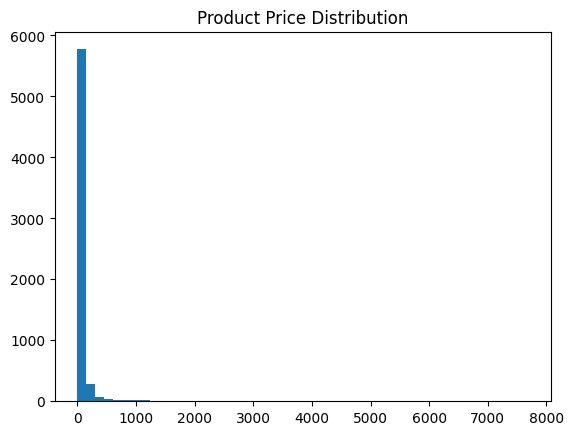

In [56]:
price_pd = meta_df.select("price_numeric") \
    .filter("price_numeric IS NOT NULL") \
    .sample(0.2) \
    .toPandas()

import matplotlib.pyplot as plt

plt.hist(price_pd["price_numeric"], bins=50)
plt.title("Product Price Distribution")
plt.show()


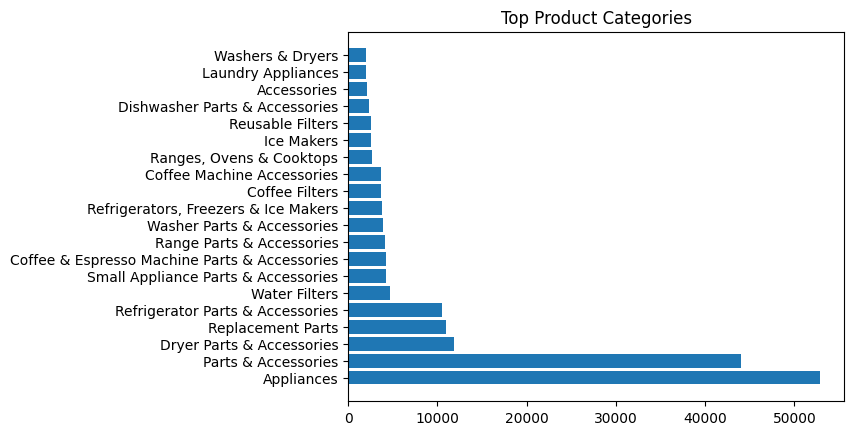

In [61]:
cat_pd = meta_cat_df.groupBy("category_exploded") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(20) \
    .toPandas()

plt.barh(cat_pd["category_exploded"], cat_pd["count"])
plt.title("Top Product Categories")
plt.show()
